# 🎬 영상 키프레임(Key Frame) 추출 (VSCode 실습용)

---

비디오에서 **핵심 장면을 대표하는 정지 이미지(키프레임)** 를 자동으로 추출하는 실습 노트북입니다.

> **실행 환경**: VSCode + Jupyter Extension + Python (로컬 환경)  
> **OpenCV 버전**: 4.10.x ~ 4.13.x (2025-2026 기준)  
> **Python 호환**: 3.9 ~ 3.13  
> **필수 확장 프로그램**: 아래 "2. VSCode 환경 설정" 섹션을 반드시 먼저 완료한 뒤 셀을 실행하세요.

### 학습 로드맵

```
환경설정 → 키프레임 개념 → 비디오 불러오기·프레임 읽기
    → I-frame 기반 키프레임 추출 (FFmpeg)
    → 프레임간 변화량 기반 키프레임 추출 (OpenCV)
    → 복수 영상 일괄 처리
```

## 0. 키프레임(Key Frame)이란?

**키프레임**은 비디오에서 중요한 장면이나 시퀀스의 시작과 끝을 표시하는 **개별 프레임**입니다.  
전체 비디오에서 중요한 순간을 대표하는 **핵심 정지 이미지**로, 비디오 압축·편집·분석에서 핵심적인 역할을 합니다.

### 키프레임 추출이 필요한 이유

| 활용 분야 | 설명 |
|-----------|------|
| **비디오 요약** | 긴 영상을 핵심 프레임만으로 빠르게 파악 |
| **썸네일 생성** | 영상 대표 이미지 자동 선택 |
| **장면 변화 감지** | 뉴스·드라마 등의 장면(shot) 경계 탐지 |
| **비디오 검색** | 이미지 기반 영상 검색(CBIR) |
| **딥러닝 학습** | 학습 데이터 효율적 구성 |

### 컬러 이미지의 3차원 텐서 구조

```
[height, width, channels]
  높이     너비    채널(B, G, R) = 3
```

> OpenCV에서 이미지(프레임)는 **NumPy 배열(ndarray)** 로 표현됩니다.  
> 예: `shape = (1080, 1920, 3)` → Full HD 프레임, BGR 3채널

## 1. 비디오 압축과 프레임 유형

### 비디오 코덱(Codec)

**코더(Coder) + 디코더(Decoder)** 의 합성어. 비디오 데이터를 **압축(인코딩)** 하고 **압축 해제(디코딩)** 하는 기술입니다.  
MP4는 일반적으로 **H.264** 또는 **H.265** 코덱으로 압축됩니다.

### 프레임 유형 (I / P / B 프레임)

비디오 코덱은 연속 프레임 간의 중복 정보를 제거하여 압축합니다. 이 과정에서 3가지 유형의 프레임이 생성됩니다.

| 프레임 유형 | 설명 | 특징 |
|------------|------|------|
| **I-frame** (Intra-coded) | 완전한 이미지 데이터를 포함하는 **독립 프레임** | 다른 프레임에 의존하지 않음 |
| **P-frame** (Predicted) | 이전 프레임과의 **차이만 저장** | 앞 방향 예측 |
| **B-frame** (Bi-directional) | 앞뒤 프레임과의 **차이만 저장** | 양방향 예측, 압축률 최고 |

```
I ──→ P ──→ B ──→ B ──→ P ──→ B ──→ B ──→ I ──→ ...
│     │                   │                   │
└── 기준 ──→ 예측 기반 ──→ 예측 기반 ──→ 새 기준 ──→
```

> **I-frame을 키프레임으로 추출**하면, 빠르게 적은 수의 대략적 키프레임을 확보할 수 있습니다.  
> **프레임간 변화량 기준**으로 추출하면 더 정교한 키프레임 선별이 가능합니다.



## 2. VSCode 환경 설정 (확장 프로그램 → 가상환경 → 커널 선택)

> ⚠️ **셀 실행(▶ 버튼)이 계속 돌아가거나 결과가 나오지 않는 경우**, 대부분 아래 설정이 빠져 있기 때문입니다.

---

### 2-1. 필수 확장 프로그램 설치 (최초 1회)

VSCode 왼쪽 사이드바 **확장(Extensions)** 아이콘 클릭 (또는 `Ctrl+Shift+X`)  
아래 2개를 검색하여 설치:

| 확장 프로그램 | 설명 |
|:-------------|:-----|
| **Python** (Microsoft) | 파이썬 언어 지원, 인터프리터 선택 |
| **Jupyter** (Microsoft) | `.ipynb` 노트북 실행, 셀 단위 실행 지원 |

> 💡 "Jupyter" 확장을 설치하면 `Jupyter Keymap`, `Jupyter Notebook Renderers` 등이 함께 설치됩니다.  
> 설치 후 **VSCode를 재시작(Reload)** 하세요.

---

### 2-2. 터미널 열기

VSCode 상단 메뉴: **터미널(Terminal) → 새 터미널(New Terminal)**  
또는 단축키: `` Ctrl+` `` (백틱)

---

### 2-3. 가상환경 생성 및 활성화

터미널에 아래 명령어를 **순서대로** 입력:

```bash
# 1) .venv 가상환경 생성 (최초 1회)
python -m venv .venv

# 2) 가상환경 활성화
# Windows:
.venv\Scripts\activate
# Mac/Linux:
source .venv/bin/activate

# 3) 활성화 확인: 터미널 프롬프트 앞에 (.venv) 표시되면 성공
```

---

### 2-4. 필수 패키지 설치

가상환경이 활성화된 상태에서:

```bash
pip install opencv-python numpy matplotlib Pillow requests ipykernel
```

> 💡 **ffmpeg**는 별도 설치가 필요합니다:
> - **Windows**: [ffmpeg.org](https://ffmpeg.org/) 에서 다운로드 후 PATH에 추가
> - **Mac**: `brew install ffmpeg`
> - **Linux**: `sudo apt install ffmpeg`

| 패키지 | 용도 |
|--------|------|
| `opencv-python` | OpenCV 라이브러리 (GUI 포함, 로컬 환경용) |
| `numpy` | 수치 배열과 수학 연산 (이미지 = NumPy 배열) |
| `matplotlib` | 이미지 표시 및 시각화 (VSCode 노트북에서 필수) |
| `Pillow` | Python Imaging Library (PIL), 간단한 이미지 처리 |
| `requests` | URL에서 이미지 다운로드 |
| `ipykernel` | VSCode Jupyter 커널 지원 |

---

### 2-5. 커널(Kernel) 선택 — 셀 실행의 핵심

노트북 파일(`.ipynb`)을 열면 **우측 상단**에 커널 선택 버튼이 있습니다:

1. 우측 상단의 **"커널 선택(Select Kernel)"** 클릭
2. **"Python Environments..."** 선택
3. 목록에서 **`.venv (Python 3.x.x)`** 선택

> ⚠️ **커널이 선택되지 않으면 셀을 실행해도 아무 결과가 나오지 않거나 계속 로딩됩니다.**

---

### 🔧 트러블슈팅

| 증상 | 해결 방법 |
|:-----|:---------|
| ▶ 클릭 후 `[*]`로 계속 대기 | 커널이 선택되지 않음 → 우측 상단에서 커널 선택 |
| "No kernel" 또는 커널 목록이 비어 있음 | `pip install ipykernel` 실행 후 VSCode 재시작 |
| 커널은 선택했는데 실행 안 됨 | Jupyter 확장 프로그램 미설치 → `Ctrl+Shift+X`에서 "Jupyter" 설치 |
| `ModuleNotFoundError: cv2` | 커널이 `.venv`가 아닌 시스템 Python을 가리킴 → 커널 재선택 |
| `ffmpeg: command not found` | ffmpeg 미설치 → 위 2-4 안내 참고 |

In [1]:
# ──────────────────────────────────────────────────
# ✅ 환경 확인 — 이 셀을 가장 먼저 실행하세요
# 아래 결과가 정상 출력되면 환경 설정 완료!
# ──────────────────────────────────────────────────
import sys                              # 시스템 정보 모듈
print(f"Python 버전: {sys.version}")      # 파이썬 버전 출력
print(f"Python 경로: {sys.executable}")    # 파이썬 실행 경로

import cv2                              # OpenCV: 비디오/이미지 처리
import numpy as np                      # NumPy: 수치 연산
import matplotlib                       # matplotlib: 시각화
import matplotlib.pyplot as plt         # pyplot: 이미지 표시용

print(f"OpenCV 버전: {cv2.__version__}")
print(f"NumPy 버전: {np.__version__}")
print(f"matplotlib 버전: {matplotlib.__version__}")

# ffmpeg 설치 여부 확인 (I-frame 추출에 필요)
import subprocess
try:
    result = subprocess.run(['ffmpeg', '-version'], capture_output=True, text=True)
    ffmpeg_version = result.stdout.split('\n')[0]  # 첫 번째 줄만 추출
    print(f"FFmpeg: {ffmpeg_version}")
except FileNotFoundError:
    print("⚠️ FFmpeg가 설치되지 않았습니다. I-frame 추출 기능을 사용하려면 설치가 필요합니다.")

print("🎉 Jupyter 커널 연결 성공! 셀 실행이 정상 작동합니다.")

Python 버전: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
Python 경로: /home/jh/vscode/ipynb/.venv/bin/python
OpenCV 버전: 4.13.0
NumPy 버전: 2.2.6
matplotlib 버전: 3.10.8
FFmpeg: ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
🎉 Jupyter 커널 연결 성공! 셀 실행이 정상 작동합니다.


## 3. 라이브러리 불러오기

키프레임 추출에 필요한 핵심 라이브러리를 불러옵니다.  
VSCode 노트북에서는 **matplotlib**로 이미지를 표시합니다 (Colab의 `cv2_imshow` 대신).

In [2]:
# ──────────────────────────────────────────────────
# 필수 라이브러리 불러오기
# ──────────────────────────────────────────────────
import cv2                        # OpenCV: 비디오 읽기, 프레임 비교 (absdiff)
import numpy as np                # NumPy: 수치 배열 연산
import matplotlib.pyplot as plt   # matplotlib: 프레임 이미지 표시 (VSCode 노트북용)
import subprocess                 # subprocess: FFmpeg 명령어 외부 실행
import os                         # os: 파일/디렉토리 생성·탐색

# 버전 확인
print(f"OpenCV 버전: {cv2.__version__}")
print(f"NumPy 버전: {np.__version__}")

OpenCV 버전: 4.13.0
NumPy 버전: 2.2.6


In [3]:
# ──────────────────────────────────────────────────
# 이미지 표시 헬퍼 함수 정의
#   VSCode 노트북에서는 cv2.imshow() 대신 matplotlib 사용
#   이 함수를 이후 모든 셀에서 재사용
# ──────────────────────────────────────────────────
def imshow(title, image):
    """OpenCV 이미지를 matplotlib로 표시하는 헬퍼 함수"""
    plt.figure(figsize=(8, 5))
    if len(image.shape) == 3:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def imshow_compare(titles, images, figsize=(16, 5)):
    """여러 이미지를 나란히 비교하는 함수"""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, title, img in zip(axes, titles, images):
        if len(img.shape) == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print("헬퍼 함수 정의 완료: imshow(), imshow_compare()")

헬퍼 함수 정의 완료: imshow(), imshow_compare()


## 4. OpenCV로 비디오 파일 불러와 프레임 읽기

### `cv2.VideoCapture()` — 비디오 읽기의 핵심

| 메서드/속성 | 설명 |
|------------|------|
| `cv2.VideoCapture(path)` | 비디오 파일 열기 |
| `cap.isOpened()` | 파일이 정상적으로 열렸는지 확인 |
| `cap.read()` | 다음 프레임 1개 읽기 → `(success, frame)` 반환 |
| `cap.get(cv2.CAP_PROP_FRAME_COUNT)` | 총 프레임 수 |
| `cap.get(cv2.CAP_PROP_FPS)` | 초당 프레임 수 (FPS) |
| `cap.get(cv2.CAP_PROP_FRAME_WIDTH)` | 프레임 너비 |
| `cap.get(cv2.CAP_PROP_FRAME_HEIGHT)` | 프레임 높이 |
| `cap.set(cv2.CAP_PROP_POS_FRAMES, n)` | n번째 프레임으로 이동 |
| `cap.release()` | 리소스 해제 |

> **주의**: 유튜브 URL에서 직접 불러올 수 없습니다. 로컬 파일 경로가 필요합니다.  
> `cap.read()`는 한 번에 프레임 1개만 읽습니다. 전체 프레임을 읽으려면 **반복문**이 필요합니다.  
> `success`가 `False`이면 프레임 읽기 실패(비디오 끝에 도달했거나 오류 발생)입니다.

비디오 경로: sample_video.mp4
총 프레임 수: 1,535
FPS: 30.0
해상도: 640 x 360
영상 길이: 51.2초 (0.9분)

프레임 shape: (360, 640, 3)
프레임 dtype: uint8


/tmp/ipykernel_31367/2815335664.py:15: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31367/2815335664.py:15: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31367/2815335664.py:15: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31367/2815335664.py:15: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31367/2815335664.py:15: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31367/2815335664.py:15: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jh/vscode/ipynb/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52395 (\N{HANGUL SYLL

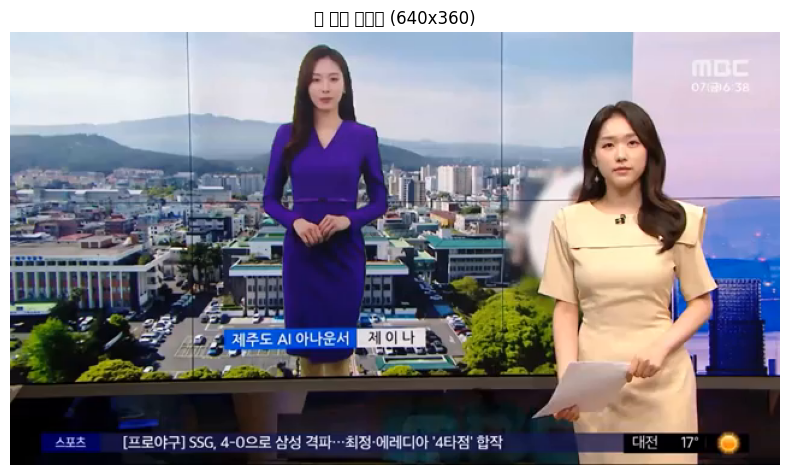

In [5]:
# ──────────────────────────────────────────────────
# 비디오 파일 불러오기 및 기본 정보 확인
# ──────────────────────────────────────────────────

# ⚠️ 아래 경로를 본인의 비디오 파일 경로로 변경하세요
video_path = 'sample_video.mp4'  # 예: './data/news_clip.mp4'

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"⚠️ 비디오 파일을 열 수 없습니다: {video_path}")
    print("   → 파일 경로를 확인하세요.")
else:
    # 비디오 기본 정보 출력
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = total_frames / fps if fps > 0 else 0

    print(f"비디오 경로: {video_path}")
    print(f"총 프레임 수: {total_frames:,}")
    print(f"FPS: {fps:.1f}")
    print(f"해상도: {width} x {height}")
    print(f"영상 길이: {duration:.1f}초 ({duration/60:.1f}분)")

    # 첫 번째 프레임 읽기 및 표시
    success, frame = cap.read()
    if success:
        print(f"\n프레임 shape: {frame.shape}")  # (높이, 너비, 채널)
        print(f"프레임 dtype: {frame.dtype}")      # uint8
        imshow(f'첫 번째 프레임 ({width}x{height})', frame)
    
    cap.release()

## 5. I-frame 기반 키프레임 추출 (FFmpeg)

### FFmpeg란?

**"Fast Forward MPEG"** 의 약자로, 비디오/오디오를 **변환, 편집, 추출, 스트리밍**할 수 있는 오픈소스 프로그램입니다.  
파이썬 코드가 아니라 **명령줄(CLI)에서 직접 실행**하며, Python에서는 `subprocess` 모듈로 호출합니다.

### I-frame 추출 원리

I-frame은 비디오의 **완전한 이미지 데이터**를 포함하는 핵심 프레임입니다.  
다른 프레임들(P, B)은 I-frame을 기준으로 예측·생성되므로, I-frame만 추출하면 빠르게 대략적 키프레임을 확보할 수 있습니다.

### 사용하는 FFmpeg 명령어

```bash
# I-frame만 선택하여 이미지로 저장
ffmpeg -i input.mp4 -vf "select=eq(pict_type,I)" -vsync vfr -f image2 output/f_%d.jpg
```

| 옵션 | 설명 |
|------|------|
| `-i input.mp4` | 입력 비디오 파일 |
| `-vf "select=eq(pict_type,I)"` | 비디오 필터: I-프레임만 선택 |
| `-vsync vfr` | 가변 프레임 레이트로 출력 |
| `-f image2` | 출력 형식을 이미지 파일로 지정 |
| `output/f_%d.jpg` | 출력 파일명 형식 (`%d` = 프레임 번호) |

### ffprobe로 총 프레임 수 확인

```bash
ffprobe -v error -select_streams v:0 -show_entries stream=nb_frames -of default=nokey=1:noprint_wrappers=1 input.mp4
```

In [6]:
# ──────────────────────────────────────────────────
# I-frame(키프레임) 추출 함수 — FFmpeg 기반
# ──────────────────────────────────────────────────
import subprocess                       # 외부 명령어(ffmpeg/ffprobe) 실행
import os                               # 파일/디렉토리 처리

def extract_iframes(video_path, base_folder):
    """
    FFmpeg를 사용하여 I-frame(키프레임)을 추출하는 함수

    Args:
        video_path (str): 비디오 파일 경로
        base_folder (str): 출력 폴더 경로

    Returns:
        tuple: (총 프레임 수, I-frame 수)
    """
    # 비디오 파일 이름에서 확장자를 제외한 기본 이름 추출
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    # 출력 폴더 경로 구성: base_folder/비디오이름/
    output_folder = os.path.join(base_folder, base_name)
    # 출력 폴더가 없으면 자동 생성 (exist_ok=True: 이미 있어도 에러 안 남)
    os.makedirs(output_folder, exist_ok=True)

    # ── ffprobe: 총 프레임 수 확인 ──
    ffprobe_cmd = [
        'ffprobe',                                    # ffprobe 실행
        '-v', 'error',                                # 에러 메시지만 출력
        '-select_streams', 'v:0',                     # 첫 번째 비디오 스트림 선택
        '-show_entries', 'stream=nb_frames',          # 총 프레임 수 항목만 표시
        '-of', 'default=nokey=1:noprint_wrappers=1',  # 순수 숫자값만 출력
        str(video_path)                               # 입력 비디오 경로
    ]
    # ffprobe 실행 후 출력값을 정수로 변환
    total_frames = int(subprocess.check_output(ffprobe_cmd).decode().strip())

    # ── ffmpeg: I-frame 추출 ──
    # subprocess 리스트 모드에서는 쉘 이스케이프 불필요 → 쉼표 그대로 사용
    command = [
        'ffmpeg',                                     # ffmpeg 실행
        '-i', video_path,                             # 입력 비디오 파일
        '-vf', 'select=eq(pict_type\,I)',             # 비디오 필터: I-프레임만 선택
        '-vsync', 'vfr',                              # 가변 프레임 레이트로 출력
        '-f', 'image2',                               # 출력 형식: 이미지 파일
        f'{output_folder}/f_%d.jpg'                   # 출력 파일명 (%d=순번)
    ]
    # ffmpeg 실행 (stdout/stderr 캡처하여 화면에 안 보이게)
    subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

    # 추출된 I-프레임 수 = 출력 폴더의 .jpg 파일 개수
    i_frame_count = len([f for f in os.listdir(output_folder) if f.endswith('.jpg')])

    return total_frames, i_frame_count

print("extract_iframes() 함수 정의 완료")

extract_iframes() 함수 정의 완료


총 프레임 수: 1,535
추출된 I-frame 수: 15
압축비: 102.3x (전체 대비 1.0%)

저장 위치: ./output/iframes/


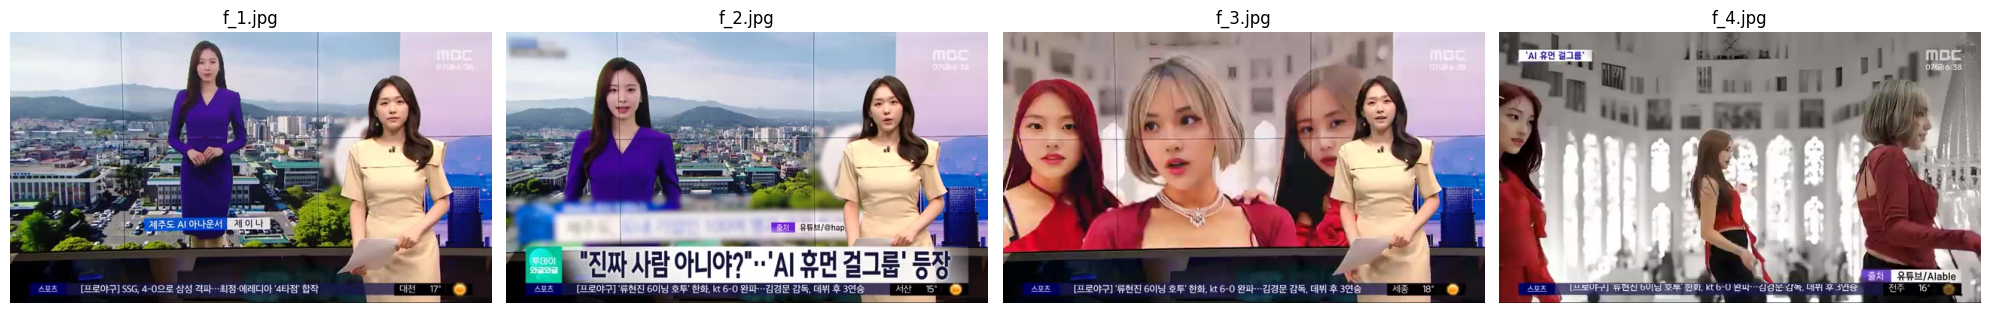

In [8]:
# ──────────────────────────────────────────────────
# I-frame 추출 실습 — 영상 파일 1개
# ──────────────────────────────────────────────────

# ⚠️ 아래 경로를 본인의 파일 경로로 변경하세요
video_path = 'sample_video.mp4'
base_folder = './output/iframes/'  # I-frame이 저장될 폴더

try:
    total_frames, i_frame_count = extract_iframes(
        video_path=video_path,
        base_folder=base_folder
    )
    print(f"총 프레임 수: {total_frames:,}")
    print(f"추출된 I-frame 수: {i_frame_count}")
    print(f"압축비: {total_frames / i_frame_count:.1f}x (전체 대비 {i_frame_count/total_frames*100:.1f}%)")
    print(f"\n저장 위치: {base_folder}")

    # 추출된 I-frame 중 처음 4개 표시
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    output_folder = os.path.join(base_folder, base_name)
    iframe_files =  sorted(
        [f for f in os.listdir(output_folder) if f.endswith('.jpg')],
        key=lambda x: int(x.split('_')[1].split('.')[0])
    )

    sample_count = min(4, len(iframe_files))
    if sample_count > 0:
        sample_frames = []
        sample_titles = []
        for f in iframe_files[:sample_count]:
            img = cv2.imread(os.path.join(output_folder, f))
            sample_frames.append(img)
            sample_titles.append(f)
        imshow_compare(sample_titles, sample_frames, figsize=(20, 5))

except FileNotFoundError:
    print("⚠️ FFmpeg가 설치되지 않았습니다.")
    print("   Windows: https://ffmpeg.org/ 에서 다운로드 후 PATH에 추가")
    print("   Mac: brew install ffmpeg")
    print("   Linux: sudo apt install ffmpeg")
except Exception as e:
    print(f"⚠️ 오류 발생: {e}")
    print("   → 비디오 파일 경로를 확인하세요.")

## 6. 프레임간 변화량 기반 키프레임 추출 (OpenCV)

I-frame 기반 방법은 빠르지만 코덱 수준의 키프레임만 추출합니다.  
**프레임간 변화량**을 기준으로 추출하면 **시각적으로 의미 있는 장면 변화**를 포착할 수 있습니다.

### 원리

```
이전 프레임 → 현재 프레임 → 차이 계산(absdiff) → 변화량 > 임계값? → 키프레임!
```

1. **`cv2.absdiff(frame1, frame2)`** — 두 프레임의 **픽셀값 차이의 절대값** 계산
2. **`.sum()`** — 차이 이미지의 모든 픽셀값 합산 (3차원 텐서 → 스칼라)
3. 변화량이 **임계값(threshold)** 을 넘으면 키프레임으로 저장

### `cv2.absdiff()` 함수

```python
diff = cv2.absdiff(src1, src2)
```

| 매개변수 | 설명 |
|---------|------|
| `src1` | 첫 번째 입력 이미지 (이전 프레임) |
| `src2` | 두 번째 입력 이미지 (현재 프레임) |
| **반환값** | 두 이미지의 절대 차이 이미지 |

### 변화 임계값(change_rate) 설정

| 영상 유형 | 권장 change_rate | 설명 |
|-----------|:---------------:|------|
| **뉴스** | 0.3 ~ 0.5 | 장면 전환이 비교적 명확 |
| **드라마/영화** | 0.2 ~ 0.4 | 카메라 워크가 다양 |
| **강연/인터뷰** | 0.5 ~ 0.7 | 변화가 적어 높은 임계값 필요 |

> **change_rate가 낮을수록** 더 많은 키프레임이 추출됩니다.  
> **change_rate가 높을수록** 큰 변화만 감지하여 적은 키프레임이 추출됩니다.

In [9]:
# ──────────────────────────────────────────────────
# 프레임간 변화량 기반 키프레임 추출 함수
# ──────────────────────────────────────────────────
import cv2                              # OpenCV: 비디오 읽기, 프레임 비교
import os                               # 파일/디렉토리 처리

def extract_keyframes(video_path, base_folder, change_rate=0.4):
    """
    프레임간 변화량을 기준으로 키프레임을 추출하는 함수

    Args:
        video_path (str): 비디오 파일 경로
        base_folder (str): 출력 폴더 경로
        change_rate (float): 변화 임계값 (뉴스는 0.3~0.5 권장)

    Returns:
        tuple: (총 프레임 수, 키프레임 수)
    """
    # 비디오 파일명에서 확장자 제외한 이름 추출
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    output_folder = os.path.join(base_folder, base_name)  # 출력 폴더 경로
    os.makedirs(output_folder, exist_ok=True)              # 폴더 자동 생성

    # 비디오 파일 열기
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():                                 # 파일 열기 실패 시
        raise Exception(f"비디오 파일을 열 수 없습니다: {video_path}")

    # 첫 프레임 읽기
    success, prev_frame = cap.read()    # success: 성공 여부, prev_frame: 프레임 이미지
    if not success:
        raise Exception("비디오 파일의 첫 프레임을 읽는 데 실패했습니다.")

    # 첫 번째 프레임은 항상 키프레임에 포함
    keyframes = [prev_frame]             # 키프레임 이미지 리스트
    frame_indices = [1]                  # 키프레임의 프레임 번호 리스트
    n_frames = 1                         # 총 프레임 카운터

    while True:
        success, curr_frame = cap.read() # 다음 프레임 읽기
        if not success:
            break                        # 비디오 끝에 도달하면 종료

        n_frames += 1                    # 프레임 카운터 증가

        # ── 핵심: 이전 프레임과 현재 프레임 간 차이 계산 ──
        # cv2.absdiff(): 두 이미지의 픽셀별 절대 차이값 계산
        diff = cv2.absdiff(curr_frame, prev_frame)

        # 변화량 판정: diff의 전체 합 > 이전 프레임 합 × change_rate
        # diff.sum(): 3차원 텐서(높이×너비×채널)의 모든 요소를 더한 스칼라값
        if diff.sum() > prev_frame.sum() * change_rate:
            keyframes.append(curr_frame)       # 키프레임으로 저장
            frame_indices.append(n_frames)     # 해당 프레임 번호 기록

        prev_frame = curr_frame          # 이전 프레임을 현재로 업데이트

    # 추출된 키프레임을 이미지 파일로 저장
    for i, (kf, idx) in enumerate(zip(keyframes, frame_indices)):
        frame_name = f"f_{i+1}_{idx}.jpg"    # 파일명: f_순번_프레임번호.jpg
        cv2.imwrite(os.path.join(output_folder, frame_name), kf)

    cap.release()                        # 비디오 리소스 해제
    return n_frames, len(keyframes)      # (총 프레임 수, 키프레임 수)

print("extract_keyframes() 함수 정의 완료")

extract_keyframes() 함수 정의 완료


총 프레임 수: 1,535
추출된 키프레임 수: 16
압축비: 95.9x (전체 대비 1.0%)
change_rate: 0.4

저장 위치: ./output/keyframes/


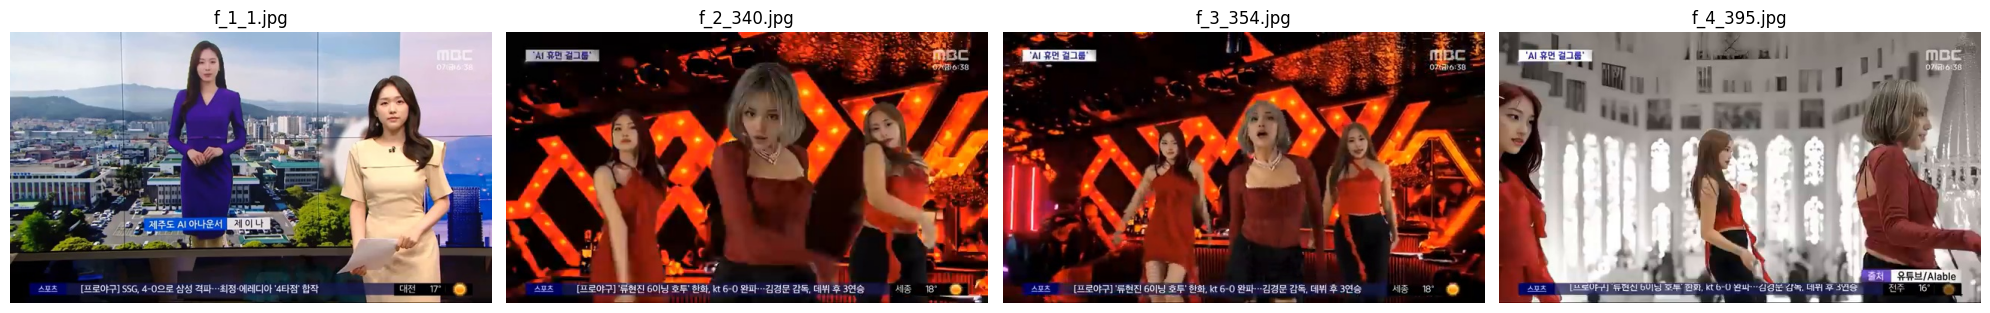

In [10]:
# ──────────────────────────────────────────────────
# 키프레임 추출 실습 — 영상 파일 1개
# ──────────────────────────────────────────────────

# ⚠️ 아래 경로를 본인의 파일 경로로 변경하세요
video_path = 'sample_video.mp4'
base_folder = './output/keyframes/'
change_rate = 0.4  # 뉴스 영상의 경우 0.3~0.5 권장

try:
    total_frames, total_keyframes = extract_keyframes(
        video_path=video_path,
        base_folder=base_folder,
        change_rate=change_rate
    )
    print(f"총 프레임 수: {total_frames:,}")
    print(f"추출된 키프레임 수: {total_keyframes}")
    print(f"압축비: {total_frames / total_keyframes:.1f}x (전체 대비 {total_keyframes/total_frames*100:.1f}%)")
    print(f"change_rate: {change_rate}")
    print(f"\n저장 위치: {base_folder}")

    # 추출된 키프레임 중 처음 4개 표시
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    output_folder = os.path.join(base_folder, base_name)
    kf_files = sorted(
        [f for f in os.listdir(output_folder) if f.endswith('.jpg')],
        key=lambda x: int(x.split('_')[1].split('.')[0])
    )

    sample_count = min(4, len(kf_files))
    if sample_count > 0:
        sample_frames = []
        sample_titles = []
        for f in kf_files[:sample_count]:
            img = cv2.imread(os.path.join(output_folder, f))
            sample_frames.append(img)
            sample_titles.append(f)
        imshow_compare(sample_titles, sample_frames, figsize=(20, 5))

except Exception as e:
    print(f"⚠️ 오류 발생: {e}")
    print("   → 비디오 파일 경로를 확인하세요.")

## 7. 복수 영상 파일 일괄 처리

여러 비디오 파일에 대해 키프레임을 한꺼번에 추출하는 방법입니다.  
결과는 리스트에 저장되어 분석에 활용할 수 있습니다.

### 처리 흐름

```
영상 파일 목록 → 반복문으로 순회 → 각 영상에서 키프레임 추출 → 결과 저장
```

In [ ]:
# ──────────────────────────────────────────────────
# 복수 영상 — I-frame 기반 일괄 추출
# ──────────────────────────────────────────────────

# ⚠️ 본인의 영상 파일 경로 목록으로 변경하세요
video_paths = [
    'video_01.mp4',
    'video_02.mp4',
    'video_03.mp4',
    'video_04.mp4',
]
base_folder = './output/iframes_batch/'

result_iframes = []
for video_path in video_paths:
    try:
        total_frames, i_frame_count = extract_iframes(video_path, base_folder)
        result_iframes.append([video_path, total_frames, i_frame_count])
        print(f"✅ {video_path}: 총 {total_frames:,}프레임 → I-frame {i_frame_count}개")
    except Exception as e:
        result_iframes.append([video_path, '', ''])
        print(f"❌ {video_path}: 처리 실패 ({e})")

print(f"\n처리 완료: {len(result_iframes)}개 영상")

In [ ]:
# ──────────────────────────────────────────────────
# 복수 영상 — 변화량 기반 일괄 추출
# ──────────────────────────────────────────────────

# ⚠️ 본인의 영상 파일 경로 목록으로 변경하세요
video_paths = [
    'video_01.mp4',
    'video_02.mp4',
    'video_03.mp4',
    'video_04.mp4',
]
base_folder = './output/keyframes_batch/'
change_rate = 0.4  # 뉴스 영상 기준

result_keyframes = []
for video_path in video_paths:
    try:
        total_frames, total_keyframes = extract_keyframes(video_path, base_folder, change_rate)
        result_keyframes.append([video_path, total_frames, total_keyframes])
        print(f"✅ {video_path}: 총 {total_frames:,}프레임 → 키프레임 {total_keyframes}개")
    except Exception as e:
        result_keyframes.append([video_path, '', ''])
        print(f"❌ {video_path}: 처리 실패 ({e})")

print(f"\n처리 완료: {len(result_keyframes)}개 영상 (change_rate={change_rate})")

## 8. 두 가지 방법 비교

| 비교 항목 | I-frame 기반 (FFmpeg) | 변화량 기반 (OpenCV) |
|-----------|:-------------------:|:-------------------:|
| **속도** | 빠름 (코덱 수준 직접 접근) | 느림 (모든 프레임 순회) |
| **정교함** | 낮음 (코덱이 정한 I-frame) | 높음 (시각적 변화 기반) |
| **의존성** | FFmpeg 설치 필요 | OpenCV만 필요 |
| **조절 가능** | 불가 (코덱 결정) | `change_rate`로 세밀 조절 |
| **적합한 상황** | 대량 영상 빠른 처리 | 정밀한 장면 분석 |

> **실무 팁**: 대규모 영상 분석 시 I-frame으로 1차 필터링 후, 필요한 구간에 대해 변화량 기반 추출을 적용하면 효율적입니다.

---

## 핵심 함수 요약 (Quick Reference)

| 카테고리 | 함수/명령어 | 설명 |
|---------|------------|------|
| **비디오 읽기** | `cv2.VideoCapture(path)` | 비디오 파일 열기 |
| | `cap.read()` | 다음 프레임 1개 읽기 → `(success, frame)` |
| | `cap.get(cv2.CAP_PROP_FRAME_COUNT)` | 총 프레임 수 |
| | `cap.get(cv2.CAP_PROP_FPS)` | 초당 프레임 수 |
| | `cap.release()` | 리소스 해제 |
| **프레임 비교** | `cv2.absdiff(img1, img2)` | 두 이미지의 절대 차이 |
| | `diff.sum()` | 차이 이미지의 전체 합 (스칼라) |
| **색상 변환** | `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` | BGR → RGB (matplotlib 표시용) |
| **이미지 저장** | `cv2.imwrite(path, img)` | 이미지를 파일로 저장 |
| **FFmpeg** | `ffmpeg -i input -vf "select=eq(pict_type,I)" ...` | I-frame 추출 |
| | `ffprobe -show_entries stream=nb_frames ...` | 총 프레임 수 확인 |
| **표시 (VSCode)** | `plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))` | matplotlib로 프레임 표시 |

### 참고 자료

- OpenCV 공식 문서: https://docs.opencv.org/4.x/
- OpenCV Video I/O: https://docs.opencv.org/4.x/d8/dfe/classcv_1_1VideoCapture.html
- FFmpeg 공식: https://ffmpeg.org/
- ffmpeg 동영상 처리: https://wikidocs.net/237717
- 컴퓨터 비전 A-Z (한국어): https://wikidocs.net/book/10740